In [173]:
import pandas as pd
import xarray as xr
import os
import re
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.signal import find_peaks

def get_filtered_filenames(folder_path):
    filenames = [
        f for f in os.listdir(folder_path)
        if f.endswith('.dat') and 'spectrum' in f and "SnV_" in f and os.path.isfile(os.path.join(folder_path, f))
    ]
    return filenames

def read_in_data(file_path):
    with open(file_path, 'r') as file:
        # read in metadata
        metadata = {}
        data_start_line = None
        for i, line in enumerate(file):
            if line.startswith("#"):
                # Extract key-value pairs from metadata
                if "=" in line:
                    key, value = line[2:].strip().split("=", 1)
                    metadata[key.strip()] = value.strip()
            else:
                data_start_line = i
                break
            
        data = pd.read_csv(file_path, sep='\t', skiprows=data_start_line, header=None)
        
        xrData = xr.Dataset(
                data_vars=dict(
                    intensity=xr.Variable('wavelength', data[1] , dict(units=r'au', long_name='Intensity')),             
                ),
                coords=dict(
                    wavelength=xr.Variable('wavelength', data[0]*1e-9, attrs=dict(units=r'nm', long_name='Wavelength')),
                    
                )
            )
    return xrData

# Lorentzian function
def lorentzian(x, x0, gamma, A):
    return A * gamma**2 / ((x - x0)**2 + gamma**2)

# Two Lorentzians
def double_lorentzian(x, x01, gamma1, A1, x02, gamma2, A2):
    return (lorentzian(x, x01, gamma1, A1) +
            lorentzian(x, x02, gamma2, A2))

# Gaussian function
def gaussian(x, x0, sigma, A):
    return A * np.exp(-(x - x0)**2 / (2 * sigma**2))

# Two Gaussians
def double_gaussian(x, x01, sigma1, A1, x02, sigma2, A2):
    return (gaussian(x, x01, sigma1, A1) +
            gaussian(x, x02, sigma2, A2))

def fit_data_with_peak_finding(x_data, y_data, model='lorentzian'):
    # Find peaks
    try:
        peaks, _ = find_peaks(y_data, height=np.max(y_data) * -0.1)  # Detect peaks above 10% of max height
        peak_indices = peaks[np.argsort(y_data[peaks])][-2:]  # Get indices of the two tallest peaks
        peak_indices = np.sort(peak_indices)  # Ensure order consistency
        
        x01_guess, x02_guess = x_data[peak_indices]
        y01_guess, y02_guess = y_data[peak_indices]
        
        if model == 'lorentzian':
            p0 = [x01_guess, 1, y01_guess,  # Initial guess for first Lorentzian
                x02_guess, 1, y02_guess]  # Initial guess for second Lorentzian
            popt, pcov = curve_fit(double_lorentzian, x_data, y_data, p0=p0)
        elif model == 'gaussian':
            p0 = [x01_guess, 1, y01_guess,  # Initial guess for first Gaussian
                x02_guess, 1, y02_guess]  # Initial guess for second Gaussian
            popt, pcov = curve_fit(double_gaussian, x_data, y_data, p0=p0)
        else:
            raise ValueError("Model must be 'lorentzian' or 'gaussian'.")
        
        return popt, pcov
    except BaseException as e:
        print("couldnt fit", end="")
        return None, None

def get_name(filename):
    match = re.search(r"spectrum_(.*?)\.dat", filename)
    if match:
        return match.group(1)
    return "error"

def wavelength_to_freq_diff(wavelength1, wavelength2):
    # Speed of light in m/s
    c = 3e8
    # Convert wavelengths from nm to meters
    lambda1_m = wavelength1 * 1e-9
    lambda2_m = wavelength2 * 1e-9
    # Calculate frequencies in Hz
    freq1 = c / lambda1_m
    freq2 = c / lambda2_m
    # Frequency difference in Hz
    freq_diff_hz = abs(freq1 - freq2)
    # Convert to GHz
    freq_diff_ghz = freq_diff_hz / 1e9
    
    return freq_diff_ghz

In [174]:
# folder_path = r"\\pi3-file\transfer\QINU\05_Data\waveguides_spectrometer"
folder_path = '/Users/colinsauerzapf/bwSyncShare/01_Uni Stuttgart/PhD/Data/2024-12-19/spectrometerlogic'

filepaths = get_filtered_filenames(folder_path)
data_dict = {}
not_fitted = []
for filepath in filepaths:
    xrData = read_in_data(f"{folder_path}/{filepath}")
    xrData['wavelength'] = xrData.wavelength * Calibration_popt[0] + Calibration_popt[1]
    popt, pcov = fit_data_with_peak_finding(np.array(xrData.wavelength), np.array(xrData.intensity))
    if popt is not None:
        xrData.attrs["name"] = get_name(filepath)
        xrData.attrs["popt"] = popt
        xrData.attrs["distance_GHz"] = wavelength_to_freq_diff(popt[0], popt[3])
        data_dict[get_name(filepath)] = xrData
    else:
        not_fitted.append(get_name(filepath))

print(not_fitted)

couldnt fitcouldnt fitcouldnt fitcouldnt fit['SnV_36_3', 'SnV_40_3', 'SnV_3_2', 'SnV_8_3']


SnV_45_3 splitting: 850 GhZ
SnV_31_3 splitting: 850 GhZ
SnV_28_3 splitting: 841 GhZ
SnV_42_3 splitting: 1035 GhZ
SnV_27_3 splitting: 943 GhZ
SnV_44_3 splitting: 1583 GhZ
SnV_24_3 splitting: 838 GhZ
spectum_SnV_4 splitting: 845 GhZ
SnV_2_3 splitting: 873 GhZ
SnV_3_3 splitting: 842 GhZ
SnV_15_3 splitting: 954 GhZ
SnV_21_3 splitting: 836 GhZ
SnV_47_3 splitting: 2312 GhZ
SnV_35_3 splitting: 1005 GhZ
SnV_19_3 splitting: 535 GhZ
SnV_2_2 splitting: 1541 GhZ
spectum_SnV_2 splitting: 1542 GhZ
SnV_11_3 splitting: 842 GhZ
SnV_41_3 splitting: 1763 GhZ
SnV_30_3 splitting: 38 GhZ
SnV_48_3 splitting: 3813916 GhZ
SnV_39_3 splitting: 1006 GhZ
spectum_SnV_1 splitting: 1075 GhZ
spectum_SnV_3 splitting: 842 GhZ
SnV_1_3 splitting: 837 GhZ
SnV_33_3 splitting: 933 GhZ
SnV_20_3 splitting: 855 GhZ
SnV_18_3 splitting: 852 GhZ
SnV_9_3 splitting: 884 GhZ
SnV_16_3 splitting: 850 GhZ
SnV_22_3 splitting: 1069 GhZ
SnV_5_3 splitting: 221 GhZ
SnV_12_3 splitting: 1293 GhZ
SnV_7_3 splitting: 818 GhZ
SnV_10_3 splitting: 3

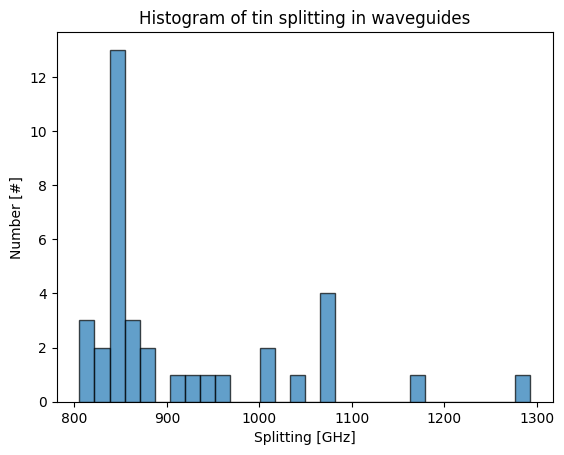

In [180]:
splittings = []
for xrData in data_dict.values():
    print(f"{xrData.attrs['name']} splitting: {xrData.attrs['distance_GHz']:.0f} GhZ")
    splittings.append(xrData.attrs['distance_GHz'])
filtered_splittings = [x for x in splittings if 750 <= x <= 1500]
plt.hist(filtered_splittings, bins=30, edgecolor='black', alpha=0.7)

# Add labels and title
plt.xlabel('Splitting [GHz]')
plt.ylabel('Number [#]')
plt.title('Histogram of tin splitting in waveguides')

# Show the plot
plt.show()


SnV_6_3 splitting: 1176 GhZ


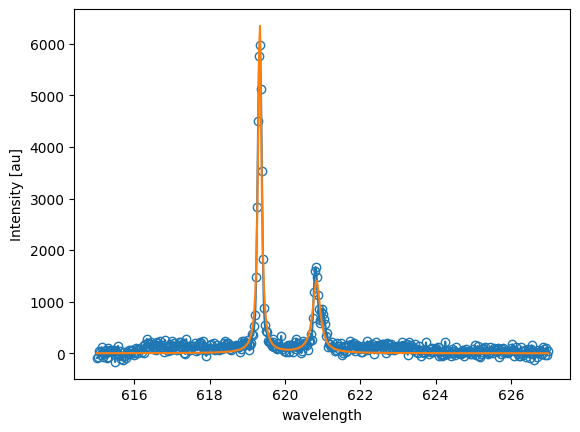

In [179]:
name = "SnV_6_3"
xrData_all = data_dict[name]
print(f"{xrData_all.attrs['name']} splitting: {xrData_all.attrs['distance_GHz']:.0f} GhZ")
xrData = xrData_all.sel(wavelength=slice(615, 627))
xrData.intensity.plot(label="Data", marker='o', fillstyle='none', linestyle='-')
fit_data = double_lorentzian(xrData.wavelength, *xrData.attrs["popt"])
plt.plot(xrData.wavelength, fit_data, label='Fitted Data')

In [194]:
def read_in_pois(filepath):
    """
    Reads a data file with metadata and converts it into an xarray.DataArray.
    Assumes the file contains metadata as commented lines (starting with '#')
    and numerical data in a tabular format.

    Parameters:
        filepath (str): Path to the file.

    Returns:
        xarray.DataArray: 2D array with x and y axes in micrometers.
    """
    # Step 1: Determine where the data starts
    with open(filepath, 'r') as file:
        metadata = {}
        data_start_line = None
        for i, line in enumerate(file):
            if line.startswith("#"):
                # Extract key-value pairs from metadata
                if "=" in line:
                    key, value = line[2:].strip().split("=", 1)
                    metadata[key.strip()] = value.strip()
            else:
                data_start_line = i
                break
    # Step 2: Read the numerical data into a Pandas DataFrame
    data = pd.read_csv(filepath, skiprows=data_start_line, delimiter='\t', header=None, names=['x', 'y', 'z'])
    data['x'] = data['x'] * 1e6
    data['y'] = data['y'] * 1e6
    data['z'] = data['z'] * 1e6
    # Step 3: Define axes in micrometers

    return data

def read_in_confocal(filepath):
    """
    Reads a data file with metadata and converts it into an xarray.DataArray.
    Assumes the file contains metadata as commented lines (starting with '#')
    and numerical data in a tabular format.

    Parameters:
        filepath (str): Path to the file.

    Returns:
        xarray.DataArray: 2D array with x and y axes in micrometers.
    """
    # Step 1: Determine where the data starts
    with open(filepath, 'r') as file:
        metadata = {}
        data_start_line = None
        for i, line in enumerate(file):
            if line.startswith("#"):
                # Extract key-value pairs from metadata
                if "=" in line:
                    key, value = line[2:].strip().split("=", 1)
                    metadata[key.strip()] = value.strip()
            else:
                data_start_line = i
                break
    # Step 2: Read the numerical data into a Pandas DataFrame
    data = pd.read_csv(filepath, skiprows=data_start_line, delimiter='\t', header=None)

    # Step 3: Define axes in micrometers
    x_range_m = eval(metadata['x scan range'])
    y_range_m = eval(metadata['y scan range'])
    x_res = int(metadata['x axis resolution'])
    y_res = int(metadata['y axis resolution'])

    x_axis = np.linspace(*x_range_m, x_res) * 1e6
    y_axis = np.linspace(*y_range_m, y_res) * 1e6   


    xrData = xr.Dataset(
        data_vars=dict(
            intensity=xr.Variable(['x', 'y'], data.values*1e-3 , dict(units=r'kCts', long_name='Intensity')),             
        ),
        coords=dict(
            x=xr.Variable('x', x_axis, attrs=dict(units=r'um', long_name='x')),
            y=xr.Variable('y', y_axis, attrs=dict(units=r'um', long_name='y')),
            
        )
    )

    return xrData, metadata

In [195]:
filepath = '/Users/colinsauerzapf/bwSyncShare/01_Uni Stuttgart/PhD/20241219-1829-45_2D-scan_with_xy_axes_from_channel_APD3_large_scan.dat'
xrData, metadata = read_in_confocal(filepath)

In [187]:
filepath = '/Users/colinsauerzapf/bwSyncShare/01_Uni Stuttgart/PhD/20241219-1900-22_Sample237_Waveguides_100keV_13_poi_list.dat'
data_pois = read_in_pois(filepath)
#data_pois

In [210]:
cmap = plt.get_cmap('summer')  # You can replace 'viridis' with any other colormap
num_colors = 1000

# Generate the list of colors
colors = [cmap(i / num_colors) for i in range(num_colors)]
def calculate_percent(value, min_value, max_value):
    percent = ((value - min_value) / (max_value - min_value)) * 100
    return percent

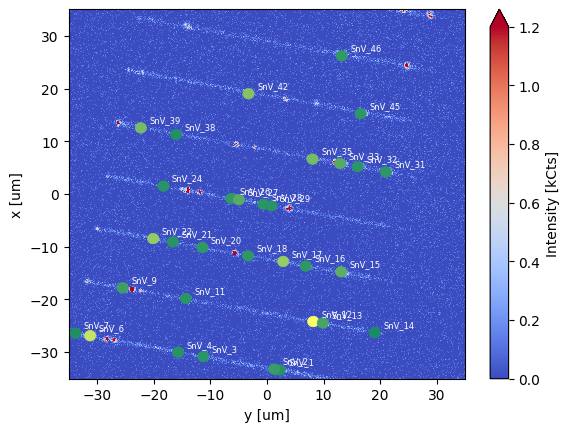

In [214]:
from matplotlib.patches import Circle
fig, ax = plt.subplots()
xrData.intensity.plot.imshow(vmax=1.2, ax=ax, cmap=plt.get_cmap('coolwarm'))

maxSplitt = 1300
minSplitt = 750 

# Add unfilled circles and labels
for x, y, label in zip(list(data_pois['x']), list(data_pois['y']), list(data_pois.index)):
    # Add circle
    if not (label + '_3') in not_fitted:
        xrData_spectrum = data_dict[label + '_3']
        if minSplitt < xrData_spectrum.attrs['distance_GHz'] < maxSplitt:
            color = colors[int(calculate_percent(xrData_spectrum.attrs['distance_GHz'], minSplitt, maxSplitt)*1e1)]
            circle = Circle((y, x), 1, color=color, fill=True, linewidth=0.5)
            ax.add_patch(circle)
    #        Add label next to the circle
            ax.text(y+1.5, x+1.5, label, color='white', fontsize=6, va='center')

In [72]:
# Calibrate spectrometer

def fit_single_with_peak_finding(x_data, y_data, model='lorentzian'):
    # Find peaks

    peaks, _ = find_peaks(y_data, height=np.max(y_data) * 0.1)  # Detect peaks above 10% of max height
    peak_indice = peaks[np.argsort(y_data[peaks])][-1]  # Get indices of the two tallest peaks  # Ensure order consistency
    
    x01_guess = x_data[peak_indice]
    y01_guess = y_data[peak_indice]
    
    p0 = [x01_guess, 1, y01_guess]  # Initial guess for second Lorentzian
    popt, pcov = curve_fit(lorentzian, x_data, y_data, p0=p0)
    
    return popt, pcov

def get_filtered_filenames_laser(folder_path):
    filenames = [
        f for f in os.listdir(folder_path)
        if f.endswith('.dat') and 'spectrum' in f and "laser" in f and os.path.isfile(os.path.join(folder_path, f))
    ]
    return filenames

In [156]:
folder_path = '/Users/colinsauerzapf/bwSyncShare/01_Uni Stuttgart/PhD/Data/spectrometer_calib'
filepaths = get_filtered_filenames_laser(folder_path)

data_dict = {}
not_fitted = []
for filepath in filepaths:
    xrData = read_in_data(f"{folder_path}/{filepath}")
    popt, pcov = fit_single_with_peak_finding(np.array(xrData.wavelength), np.array(xrData.intensity))
    if popt is not None:
        xrData.attrs["name"] = get_name(filename=filepath)
        xrData.attrs["popt"] = popt
        data_dict[get_name(filepath)] = xrData
    else:
        not_fitted.append(get_name(filepath))

print(not_fitted)

wl_spectrometer = []
wl_wavemeter = []
for xrData in data_dict.values():
   print(f"{get_wavelength(xrData.attrs['name'])} Meas_pos: {xrData.attrs['popt'][0]:.5f} nm")
   wl_spectrometer.append(xrData.attrs['popt'][0])
   wl_wavemeter.append(get_wavelength(xrData.attrs['name']))

#    splittings.append(xrData.attrs['distance_GHz'])
#filtered_splittings = [x for x in splittings if 1000 <= x <= 2000]

[]
622.42138 Meas_pos: 624.32049 nm
621.14217 Meas_pos: 622.62450 nm
623.71625 Meas_pos: 626.23459 nm
625.01542 Meas_pos: 627.49416 nm
617.57997 Meas_pos: 617.75742 nm
615.72882 Meas_pos: 615.30353 nm
619.22283 Meas_pos: 619.99999 nm


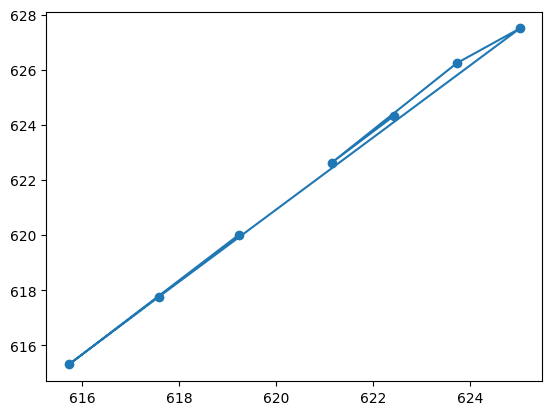

In [157]:
plt.plot(wl_wavemeter, wl_spectrometer, marker='o')

In [158]:
def get_wavelength(name):
    match = re.search(r'\d+\.\d+', name)
    return float(match.group())

def linear(x, a ,c):
    return a*x + c

Calibration_popt, pcov = curve_fit(linear, wl_spectrometer, wl_wavemeter)

In [163]:
xrData = data_dict[list(data_dict.keys())[1]].copy()
xrData['wavelength'] = xrData.wavelength * Calibration_popt[0] + Calibration_popt[1]

laser_wavemeter_621.14217
622.6244955922489


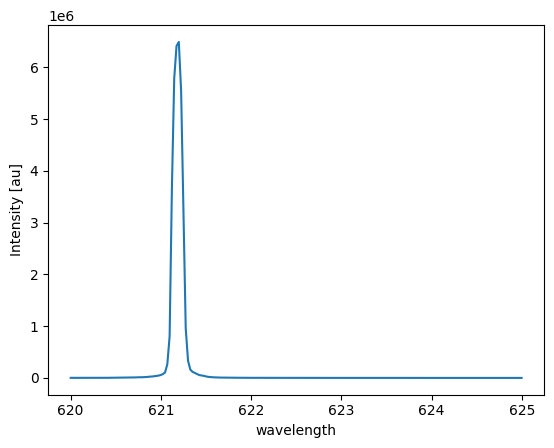

In [164]:
print(xrData.attrs['name'])
print(xrData.attrs['popt'][0])
xrData.sel(wavelength=slice(620,625)).intensity.plot()

In [155]:
Calibration_popt

array([  0.7474109 , 155.82829969])